<div class="alert alert-success">    
    <h1 style="direction: rtl;text-align:center;font-family:B Roya;font-size: 40px;">مبانی هوش محاسباتی - منطق فازی</h1>
    <h2 style="direction: rtl;text-align:center;font-family:B Roya;font-size: 25px;">مجید محبی</h2>
    <h3 style="direction: rtl;text-align:center;font-family:B Roya;font-size: 20px;">دانشکده مهندسی برق و کامپیوتر دانشگاه زنجان</h3>
    <h4 style="direction: rtl;text-align:center;font-family:B Roya;font-size: 18px;">پاییز 1404</h4>
</div>

<div style="direction: rtl; text-align: right; font-family: B Roya; font-size: 18px; color: rgb(127,96,0);">

<h2>تکلیف شماره 2 - پیاده سازی یک سیستم استنتاج فازی</h2>

</div>


<h4 style="charset:utf-8; lang:fa-IR; direction: rtl;text-align:right;font-family:B Roya;font-size: 18px;color:RGB(200,100,80)">

<body>
در این تکلیف مجاز به استفاده از ماژول control در کتابخانه skfuzzy نیستید. در صورت استفاده از این ماژول، نمره تکلیف شما صفر ثبت خواهد شد.<br>

</body> 

</h4>

<h4 style="charset:utf-8; lang:fa-IR; direction: rtl;text-align:right;font-family:B Roya;font-size: 18px;color:RGB(127,96,0)">

<body>
نام و نام خانوادگی
<br>

</body> 

</h4>

<h4 style="charset:utf-8; lang:fa-IR; direction: rtl;text-align:right;font-family:B Roya;font-size: 18px;color:RGB(127,96,0)">

<body>
شماره دانشجویی
<br>

</body> 

</h4>

In [ ]:
                                       عنوان پروژه:سیستم پیشنهاد مقدار کود برای کشاورزی

                                        وروردی ها:نوع خاک-میزان رطوبت-نوع گیاه کاشته شده  

                                                     خروجی:مقدار کود مورد نیاز   

In [15]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

#-----------------------------------------------
# 1. Define input and output domains
soil_x = np.arange(0, 11, 0.1)            
moisture_x = np.arange(0, 101, 1)      
plant_x = np.arange(0, 11, 0.1)      
fertilizer_x = np.arange(0, 101, 1)

#-----------------------------------------------
# 2. Define membership functions
def mf(x, mf_type, *params):
    if mf_type == "trapmf":
        return fuzz.trapmf(x, list(params))
    elif mf_type == "smf":
        return fuzz.smf(x, *params)
    elif mf_type == "zmf":
        return fuzz.zmf(x, *params)
    elif mf_type == "gbell":
        return fuzz.gbellmf(x, *params)
    else:
        raise ValueError("Invalid membership function type")

soil_type = {
    'x': soil_x,
    'sandy': mf(soil_x, "zmf", 2, 4),       
    'loamy': mf(soil_x, "gbell", 1.5, 3, 5),    
    'clay':  mf(soil_x, "smf", 6, 8)         
    
}
moisture = {
    'x': moisture_x,
    'low': mf(moisture_x, "zmf", 30, 50),
    'medium': mf(moisture_x, "gbell", 15, 3, 50),
    'high': mf(moisture_x, "smf", 60, 80)
}

plant_type = {
    'x': plant_x,
    'low_demand': mf(plant_x, "zmf", 3, 5),
    'medium_demand': mf(plant_x, "gbell", 2, 3, 5),
    'high_demand': mf(plant_x, "smf", 6, 9)
}

fertilizer_amount = {
    'x': fertilizer_x,
    'low': mf(fertilizer_x, "zmf", 30, 50),
    'medium': mf(fertilizer_x, "gbell", 15, 3, 50),
    'high': mf(fertilizer_x, "smf", 60, 80)
}

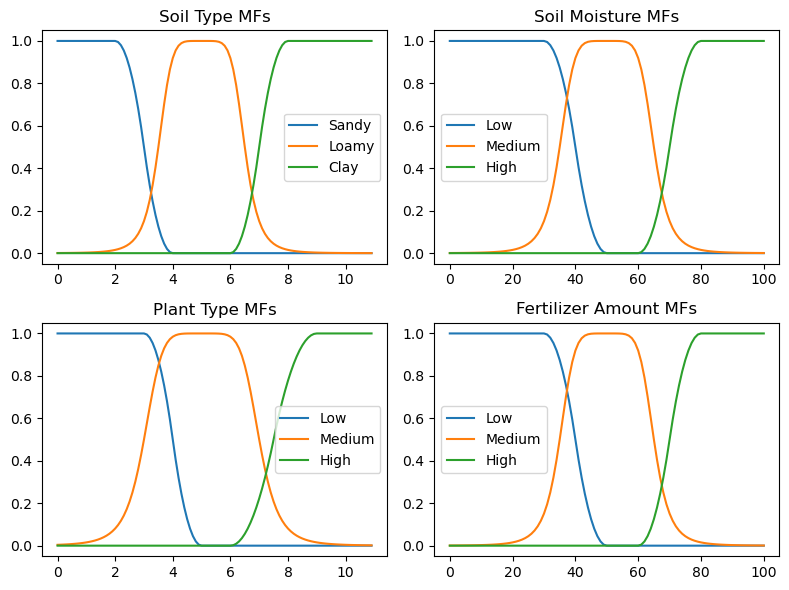

In [16]:
def plotMF():
    plt.figure(figsize=(8, 6))
    plt.subplot(2, 2, 1)
    plt.plot(soil_type['x'], soil_type['sandy'], label='Sandy')
    plt.plot(soil_type['x'], soil_type['loamy'], label='Loamy')
    plt.plot(soil_type['x'], soil_type['clay'], label='Clay')
    plt.title("Soil Type MFs"); plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(moisture['x'], moisture['low'], label='Low')
    plt.plot(moisture['x'], moisture['medium'], label='Medium')
    plt.plot(moisture['x'], moisture['high'], label='High')
    plt.title("Soil Moisture MFs"); plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(plant_type['x'], plant_type['low_demand'], label='Low')
    plt.plot(plant_type['x'], plant_type['medium_demand'], label='Medium')
    plt.plot(plant_type['x'], plant_type['high_demand'], label='High')
    plt.title("Plant Type MFs"); plt.legend()

    plt.subplot(2, 2, 4)
    plt.plot(fertilizer_amount['x'], fertilizer_amount['low'], label='Low')
    plt.plot(fertilizer_amount['x'], fertilizer_amount['medium'], label='Medium')
    plt.plot(fertilizer_amount['x'], fertilizer_amount['high'], label='High')
    plt.title("Fertilizer Amount MFs"); plt.legend()

    plt.tight_layout()
    plt.show()

plotMF()

In [17]:
# 3. Fuzzy inference 
soil_input =  8  
moisture_input = 40   #ورودی ها
plant_input = 3     

def fuzzy_inference(s_input, m_input, p_input):
    def Antecedent(mu1, mu2, mu3, method='min'):
        if method == "min":
            return np.minimum(np.minimum(mu1, mu2), mu3)
        elif method == "prod":
            return mu1 * mu2 * mu3

    def Implementation(p, qset, method='MamdaniMin'):
        if method == "MamdaniMin":
            return np.minimum(p, qset)
        elif method == "MamdaniProduct":
            return p * qset

    def Rule(s, ws, m, wm, pl, wp, fert, wf):
        mu_s = np.interp(soil_input, s['x'], s[ws])
        mu_m = np.interp(moisture_input, m['x'], m[wm])
        mu_p = np.interp(plant_input, pl['x'], pl[wp])
        p = Antecedent(mu_s, mu_m, mu_p, 'min')
        pq = Implementation(p, fert[wf], 'MamdaniMin')
        return pq 

   
    rule1 = Rule(soil_type, 'sandy', moisture, 'low', plant_type, 'low_demand', fertilizer_amount, 'high')
    rule2 = Rule(soil_type, 'sandy', moisture, 'medium', plant_type, 'low_demand', fertilizer_amount, 'medium')
    rule3 = Rule(soil_type, 'sandy', moisture, 'high', plant_type, 'low_demand', fertilizer_amount, 'low')
    rule4 = Rule(soil_type, 'loamy', moisture, 'low', plant_type, 'medium_demand', fertilizer_amount, 'medium')
    rule5 = Rule(soil_type, 'loamy', moisture, 'medium', plant_type, 'medium_demand', fertilizer_amount, 'medium')
    rule6 = Rule(soil_type, 'loamy', moisture, 'high', plant_type, 'medium_demand', fertilizer_amount, 'low')
    rule7 = Rule(soil_type, 'clay', moisture, 'low', plant_type, 'high_demand', fertilizer_amount, 'medium')
    rule8 = Rule(soil_type, 'clay', moisture, 'medium', plant_type, 'high_demand', fertilizer_amount, 'low')
    rule9 = Rule(soil_type, 'clay', moisture, 'high', plant_type, 'high_demand', fertilizer_amount, 'low')
    rule10 = Rule(soil_type, 'sandy', moisture, 'low', plant_type, 'high_demand', fertilizer_amount, 'high')
    rule11 = Rule(soil_type, 'sandy', moisture, 'medium', plant_type, 'high_demand', fertilizer_amount, 'high')
    rule12 = Rule(soil_type, 'sandy', moisture, 'high', plant_type, 'medium_demand', fertilizer_amount, 'medium')
    rule13 = Rule(soil_type, 'loamy', moisture, 'low', plant_type, 'high_demand', fertilizer_amount, 'high')
    rule14 = Rule(soil_type, 'loamy', moisture, 'high', plant_type, 'low_demand', fertilizer_amount, 'low')
    rule15 = Rule(soil_type, 'clay', moisture, 'low', plant_type, 'medium_demand', fertilizer_amount, 'medium')
    rule16 = Rule(soil_type, 'clay', moisture, 'medium', plant_type, 'low_demand', fertilizer_amount, 'low')

    return rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9,rule10, rule11, rule12, rule13, rule14, rule15, rule16
     


rules = fuzzy_inference(soil_input, moisture_input, plant_input)
print('The rules were evaluated.')


The rules were evaluated.


In [18]:
def aggregate_rules(rules, agg_method='Maximum'):
    if agg_method == "Maximum":
        aggregated = np.maximum.reduce(rules)
    elif agg_method == "Average":
        aggregated = np.mean(rules, axis=0)
    return aggregated

aggregated_result = aggregate_rules(rules, agg_method='Maximum')
print('Aggregation was done.')

Aggregation was done.


In [19]:
def defuzzify(x, mf, method='centroid'):
    if method == 'centroid':
        return fuzz.defuzz(x, mf, 'centroid')
    elif method == 'bisector':
        return fuzz.defuzz(x, mf, 'bisector')
    elif method == 'lom':
        return fuzz.defuzz(x, mf, 'lom')
    elif method == 'som':
        return fuzz.defuzz(x, mf, 'som')
    elif method == 'mom':
        return fuzz.defuzz(x, mf, 'mom')

output = defuzzify(fertilizer_amount['x'], aggregated_result, 'centroid')
print(f"Defuzzified Fertilizer Amount: {output:.2f}")


Defuzzified Fertilizer Amount: 29.79


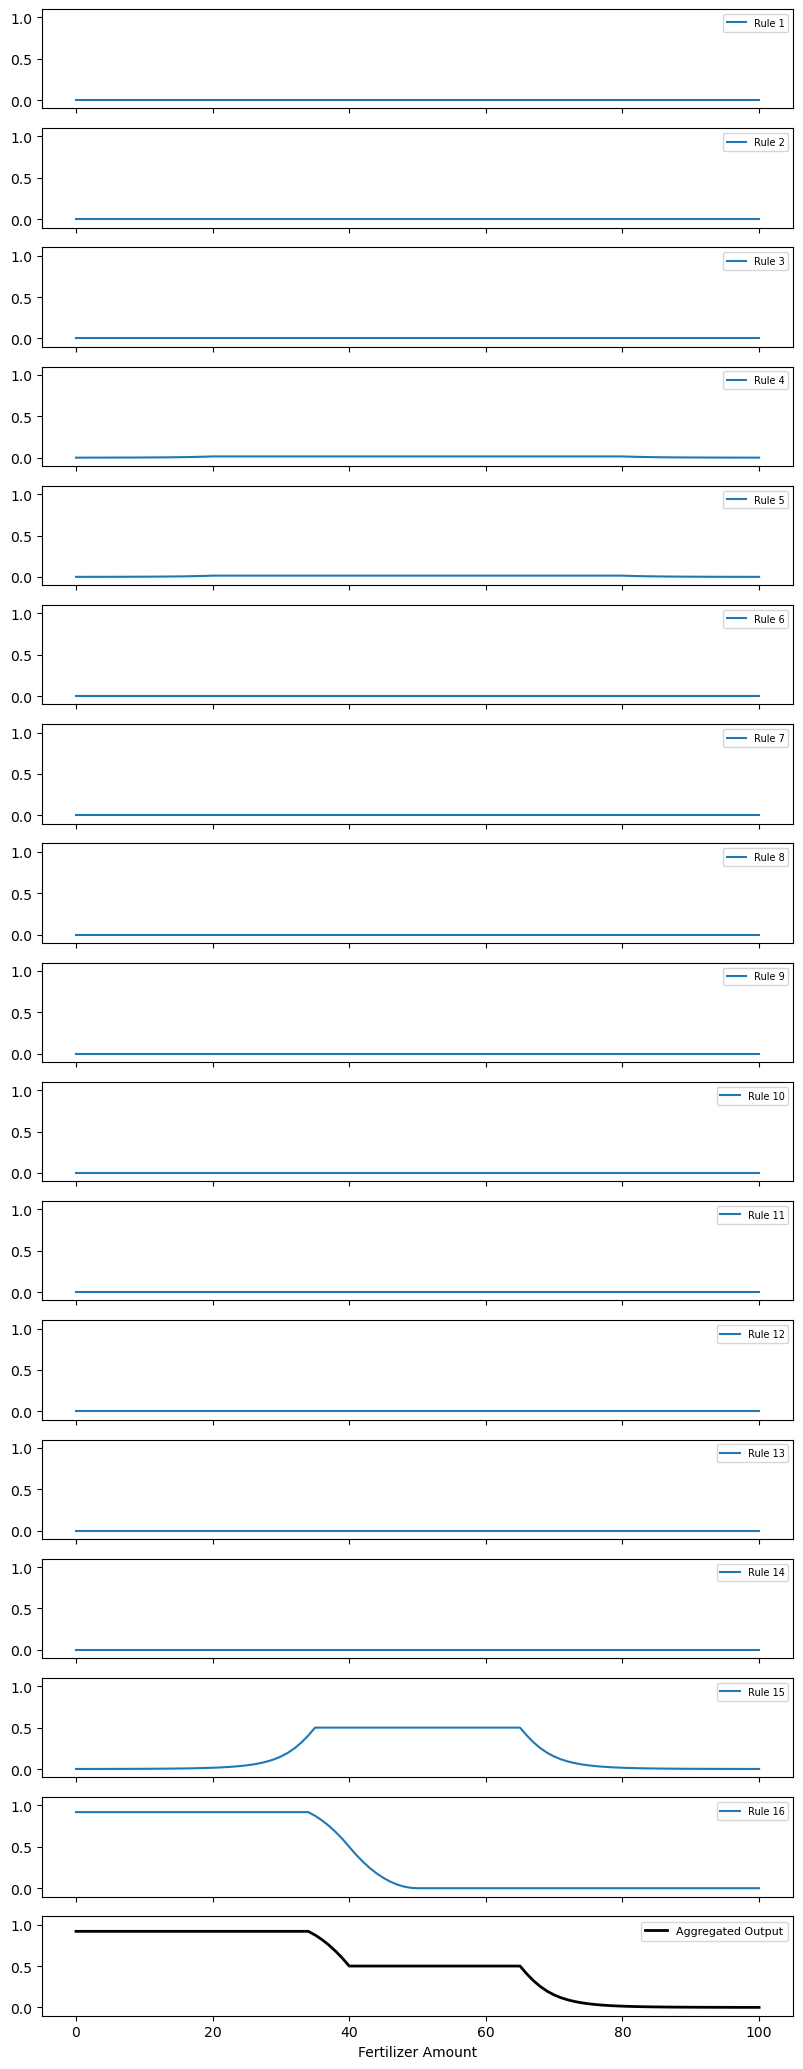

In [20]:
def plot_rules_and_aggregated(rules, aggregated, x_range):
    n_rules = len(rules)
    fig, axes = plt.subplots(n_rules + 1, 1, figsize=(8, n_rules * 1.3), sharex=True)

    
    for i, rule in enumerate(rules):
        axes[i].plot(x_range, rule, label=f'Rule {i + 1}')
        axes[i].legend(loc='upper right', fontsize=7)
        axes[i].set_ylim(-0.1, 1.1)

    
    axes[-1].plot(x_range, aggregated, 'k', linewidth=2, label='Aggregated Output')
    axes[-1].legend(loc='upper right', fontsize=8)
    axes[-1].set_ylim(-0.1, 1.1)
    axes[-1].set_xlabel("Fertilizer Amount")

    plt.tight_layout()
    plt.show()



plot_rules_and_aggregated(rules, aggregated_result, fertilizer_amount['x'])
